In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


1. SISTEMA: original (Gm0) i simplificat (Gm)

In [2]:
# Gm0(s) = (s+1)/(s+3)(0.05s+1)
numG = [1, 1]
denG0 = np.polymul([1, 3], [0.05, 1])
G_m0 = signal.lti(numG, denG0)

# Gm(s) = (s+1)/(s+3)
denG = [1, 3]  # (s+3)
G_m  = signal.lti(numG, denG)

poles = np.roots(denG)
print("Pols llaç obert:", poles)

Pols llaç obert: [-3.]


2. PID

In [3]:
err_v = 0.5

Ki = 3 / err_v
Kp = 94 / 65   # Kp i Kd obtinguts de forçar pols a -2+3j i -2-3j 
Kd = 43 / 65

# PID(s) = (Kd s^2 + Kp s + Ki)/s
numC = [Kd, Kp, Ki]
denC = [1, 0]

3. LLAÇ TANCAT

In [4]:
# open loop
num_ol = np.polymul(numC, numG)
den_ol0 = np.polymul(denC, denG0)
den_ol = np.polymul(denC, denG)

# closed loop: T = N / (D + N)
num_cl = num_ol
den_cl0 = np.polyadd(den_ol0, num_ol)
den_cl = np.polyadd(den_ol, num_ol)

G_cl0 = signal.lti(num_cl, den_cl0)
G_cl = signal.lti(num_cl, den_cl)

poles = np.roots(den_cl)
print("Pols llaç tancat:", poles)

Pols llaç tancat: [-2.        +3.j -2.        -3.j -0.69767442+0.j]


4. RESPOSTA POSICIÓ i VELOCITAT en llaç obert

In [5]:
t = np.arange(0, 6, 0.0001)

U = 1
u = U * np.ones_like(t)

t_out, y_ol0, _ = signal.lsim(G_m0, U=u, T=t)
t_out, y_ol , _ = signal.lsim(G_m, U=u, T=t)

G_vel0 = signal.lti(numG, np.polymul(denG0, [1, 0]))
G_vel = signal.lti(numG, np.polymul(denG, [1, 0]))

t_out, vel_ol0, _ = signal.lsim(G_vel0, U=u, T=t)
t_out, vel_ol, _ = signal.lsim(G_vel, U=u, T=t)

5. RESPOSTA POSICIÓ i VECOLCITAT en llaç tancat

In [6]:
t_out, pos0, _ = signal.lsim(G_cl0, U=u, T=t)
t_out, pos, _ = signal.lsim(G_cl, U=u, T=t)

G_cl_vel0 = signal.lti(num_cl, np.polymul(den_cl0, [1, 0]))
G_cl_vel = signal.lti(num_cl, np.polymul(den_cl, [1, 0]))

t_out, vel0, _ = signal.lsim(G_cl_vel0, U=u, T=t)
t_out, vel, _ = signal.lsim(G_cl_vel, U=u, T=t)

6. Diagrames respostes

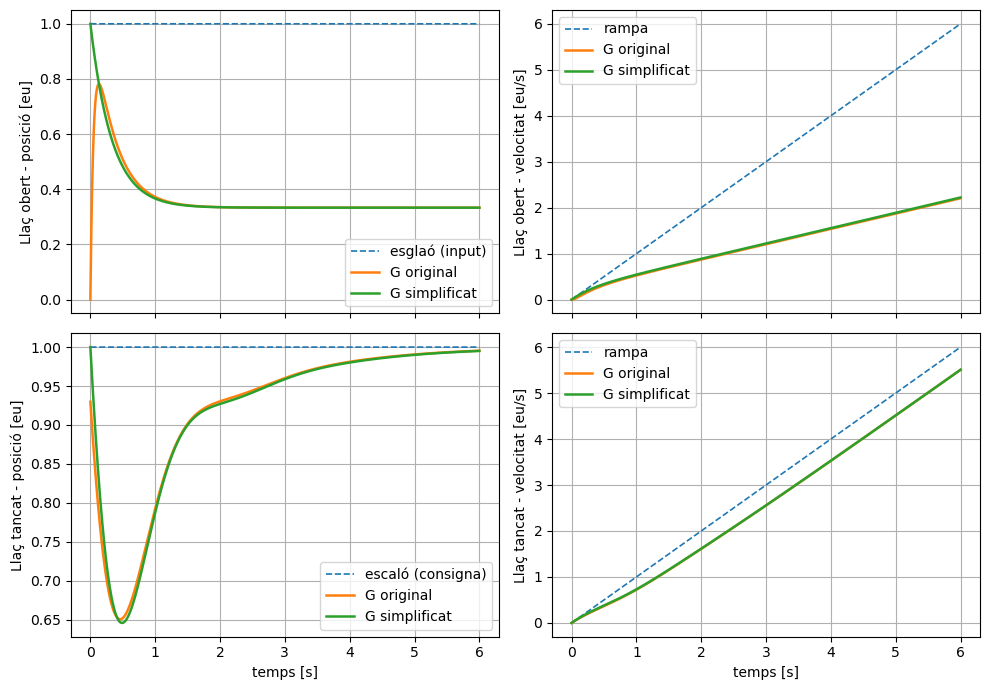

: 

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

axs[0,0].plot(t, u, '--', linewidth=1.2, label='esglaó (input)')
axs[0,0].plot(t_out, y_ol0, linewidth=1.8, label='G original')
axs[0,0].plot(t_out, y_ol, linewidth=1.8, label='G simplificat')
# axs[0,0].set_title('Llaç obert - posició')
axs[0,0].set_ylabel('Llaç obert - posició [eu]')
axs[0,0].grid(True)
axs[0,0].legend()

axs[0,1].plot(t, t, '--', linewidth=1.2, label='rampa')
axs[0,1].plot(t_out, vel_ol0, linewidth=1.8, label='G original')
axs[0,1].plot(t_out, vel_ol, linewidth=1.8, label='G simplificat')
#axs[0,1].set_title('Llaç obert - velocitat')
axs[0,1].set_ylabel('Llaç obert - velocitat [eu/s]')
axs[0,1].grid(True)
axs[0,1].legend()

axs[1,0].plot(t, u, '--', linewidth=1.2, label='escaló (consigna)')
axs[1,0].plot(t_out, pos0, linewidth=1.8, label='G original')
axs[1,0].plot(t_out, pos, linewidth=1.8, label='G simplificat')
#axs[1,0].set_title('Llaç tancat - posició')
axs[1,0].set_xlabel('temps [s]')
axs[1,0].set_ylabel('Llaç tancat - posició [eu]')
axs[1,0].grid(True)
axs[1,0].legend()

axs[1,1].plot(t, t, '--', linewidth=1.2, label='rampa')
axs[1,1].plot(t_out, vel0, linewidth=1.8, label='G original')
axs[1,1].plot(t_out, vel, linewidth=1.8, label='G simplificat')
#axs[1,1].set_title('Llaç tancat - velocitat')
axs[1,1].set_xlabel('temps [s]')
axs[1,1].set_ylabel('Llaç tancat - velocitat [eu/s]')
axs[1,1].grid(True)
axs[1,1].legend()

plt.tight_layout()
#plt.savefig('CSM_Exemple_3_PID_pols_SOL.pdf', bbox_inches='tight', transparent=True)
plt.show()